# 04 — Figuras pra apresentação

Renderiza todas as PNGs do `imagens_para_claude_code.md` em `figs/`.

- Lista A (existentes): re-gera V2, V3, V6, V11, V12, V14, V15.
- Lista B (novas): V13, V16, V17, V18, V20, V21.
- Bônus: matrizes de associação feature × feature × label (vC).

Todos os PNGs são salvos em **150 dpi**, fundo branco, sem título matplotlib
(o slide vai botar o título por cima). Re-executar este notebook recria as
PNGs.

## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import sweep_utils as sw

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
DATA = Path("../../data/toniot")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

COLOR_BY_MODEL = {
    "BTHOWeN":    "#1f77b4",
    "ClusWiSARD": "#d62728",
    "WiSARD":     "#2ca02c",
    "BloomWiSARD":"#9467bd",
    "ULEEN":      "#ff7f0e",
}
THERMO_COLORS = {
    "Simple":"#1f77b4", "Distributive":"#2ca02c",
    "Gaussian":"#d62728", "Exponential":"#ff7f0e",
}
TIER_COLORS = {"verde":"#2ca02c", "amarelo":"#ffd700",
               "laranja":"#ff7f0e", "vermelho":"#d62728"}
TIER_OF = {
    "Weather":"verde", "GPS_Tracker":"verde",
    "Modbus":"amarelo",
    "Fridge":"laranja", "Thermostat":"laranja", "Motion_Light":"laranja",
    "Garage_Door":"vermelho",
}

df = sw.load_all_results("results")
print(f"rows: {len(df):,}  ·  bases: {sorted(df.base.dropna().unique())}")

rows: 32,316  ·  bases: ['Fridge', 'GPS_Tracker', 'Garage_Door', 'Modbus', 'Motion_Light', 'Thermostat', 'Weather']


## V2 — % attack por base

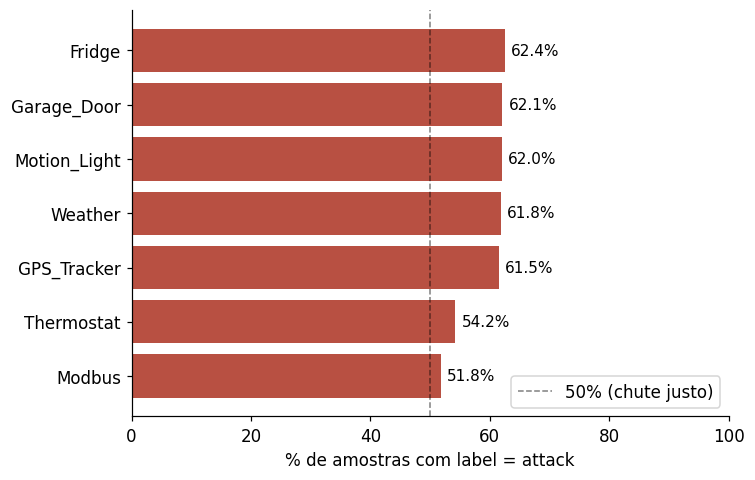

In [2]:
rows = []
for f in sorted(DATA.glob("Train_Test_IoT_*.csv")):
    base = f.stem.replace("Train_Test_IoT_", "")
    d = sw.clean_df(pd.read_csv(f))
    rows.append({"base": base, "pct": (d["label"] == 1).mean() * 100})
stats = pd.DataFrame(rows).sort_values("pct")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(stats.base, stats.pct, color="#B85042")
ax.axvline(50, color="black", lw=1, ls="--", alpha=0.5, label="50% (chute justo)")
ax.set_xlabel("% de amostras com label = attack")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")
for i, (b, p) in enumerate(zip(stats.base, stats.pct)):
    ax.text(p + 1, i, f"{p:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "v02_attack_pct.png")
plt.show()

## V3 — Heatmap base × tipo de ataque (log)

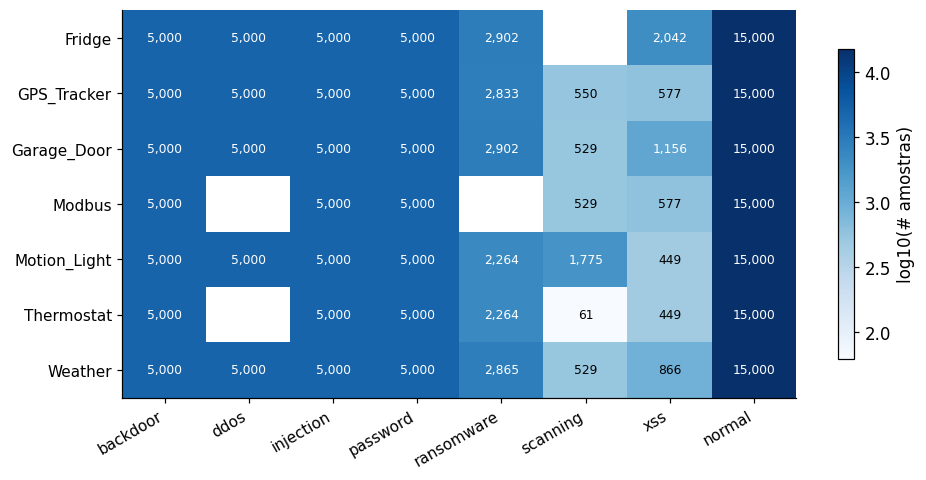

In [3]:
bases_order = sorted(df.base.dropna().unique())
all_attacks = set()
counts = {}
for base in bases_order:
    d = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    vc = d["type"].value_counts()
    counts[base] = vc
    all_attacks.update(vc.index)
attacks_order = sorted(all_attacks - {"normal"}) + (["normal"] if "normal" in all_attacks else [])

M = np.full((len(bases_order), len(attacks_order)), np.nan)
for i, b in enumerate(bases_order):
    for j, a in enumerate(attacks_order):
        if a in counts[b].index:
            M[i, j] = counts[b][a]

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(np.log10(M + 1), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(attacks_order)))
ax.set_yticks(range(len(bases_order)))
ax.set_xticklabels(attacks_order, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(bases_order, fontsize=10)
for (i, j), v in np.ndenumerate(M):
    if not np.isnan(v):
        ax.text(j, i, f"{int(v):,}", ha="center", va="center",
                color="white" if np.log10(v + 1) > 3 else "black", fontsize=8)
cbar = plt.colorbar(im, ax=ax, shrink=0.8, label="log10(# amostras)")
plt.tight_layout()
plt.savefig(FIGS / "v03_heatmap_base_attack.png")
plt.show()

## V6 — Cramér's V máx por base

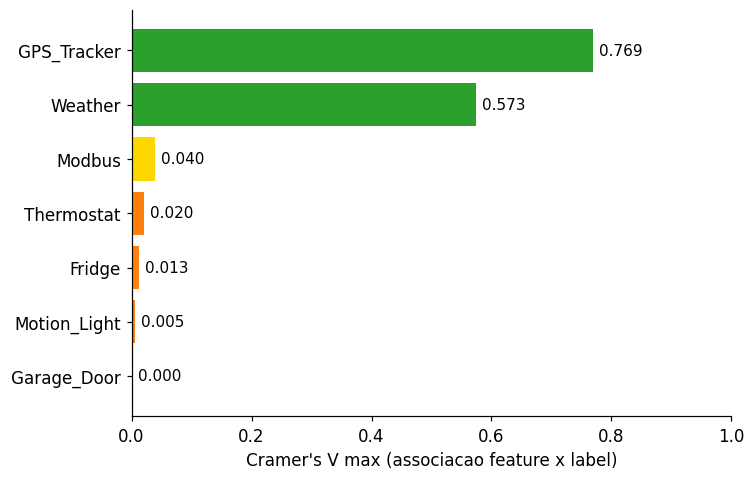

In [4]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0
    chi2, *_ = chi2_contingency(ct)
    n = ct.values.sum()
    return float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))

def discretize(s):
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 10:
        try:
            return pd.qcut(s.astype(float), 10, duplicates="drop")
        except Exception:
            return s.astype(str)
    return s.astype(str)

def cramers_max(base):
    d = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    num, cat = sw.FEATURE_COLS[base]
    vals = []
    for col in num + cat:
        vals.append(cramers_v(discretize(d[col]), d["label"]))
    return max(vals) if vals else 0.0

cramers = pd.DataFrame({"base": bases_order,
                        "v": [cramers_max(b) for b in bases_order]}
                      ).sort_values("v")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [TIER_COLORS[TIER_OF[b]] for b in cramers.base]
ax.barh(cramers.base, cramers.v, color=colors)
ax.set_xlabel("Cramer's V max (associacao feature x label)")
ax.set_xlim(0, 1)
for i, (b, v) in enumerate(zip(cramers.base, cramers.v)):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "v06_cramers_v_por_base.png")
plt.show()


## V11 — Pareto F1 × memória (cross-model)

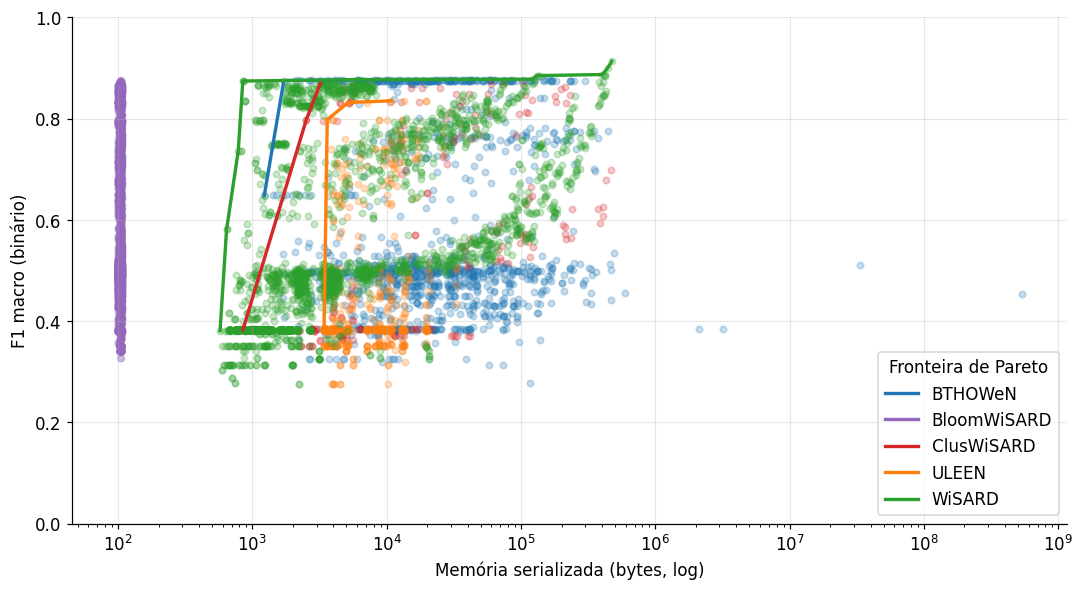

In [5]:
def pareto_front(points):
    pts = np.array(points, float)
    if len(pts) == 0:
        return np.array([], dtype=bool)
    order = np.lexsort((-pts[:, 1], pts[:, 0]))
    mask = np.zeros(len(pts), dtype=bool)
    best = -np.inf
    for idx in order:
        if pts[idx, 1] > best:
            mask[idx] = True
            best = pts[idx, 1]
    return mask

# Exclui bthowen_reference (bug memory=0)
sub = df[(df.task == "binary") & (~df.skipped)
         & df.memory_bytes_serialized.notna()
         & (df.memory_bytes_serialized > 0)
         & df.f1_macro.notna()
         & (df.submission != "bthowen_reference")]

fig, ax = plt.subplots(figsize=(10, 5.5))
for model, g in sub.groupby("model"):
    color = COLOR_BY_MODEL.get(model, "gray")
    ax.scatter(g.memory_bytes_serialized, g.f1_macro,
               alpha=0.25, s=18, color=color)
    pts = list(zip(g.memory_bytes_serialized, g.f1_macro))
    mask = pareto_front(pts)
    front = g.iloc[mask].sort_values("memory_bytes_serialized")
    ax.plot(front.memory_bytes_serialized, front.f1_macro,
            color=color, lw=2.2, label=f"{model}")
ax.set_xscale("log")
ax.set_xlabel("Memória serializada (bytes, log)")
ax.set_ylabel("F1 macro (binário)")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=11, title="Fronteira de Pareto")
plt.tight_layout()
plt.savefig(FIGS / "v11_pareto_cross_model.png")
plt.show()

## V12 — Pareto por base (small multiples)

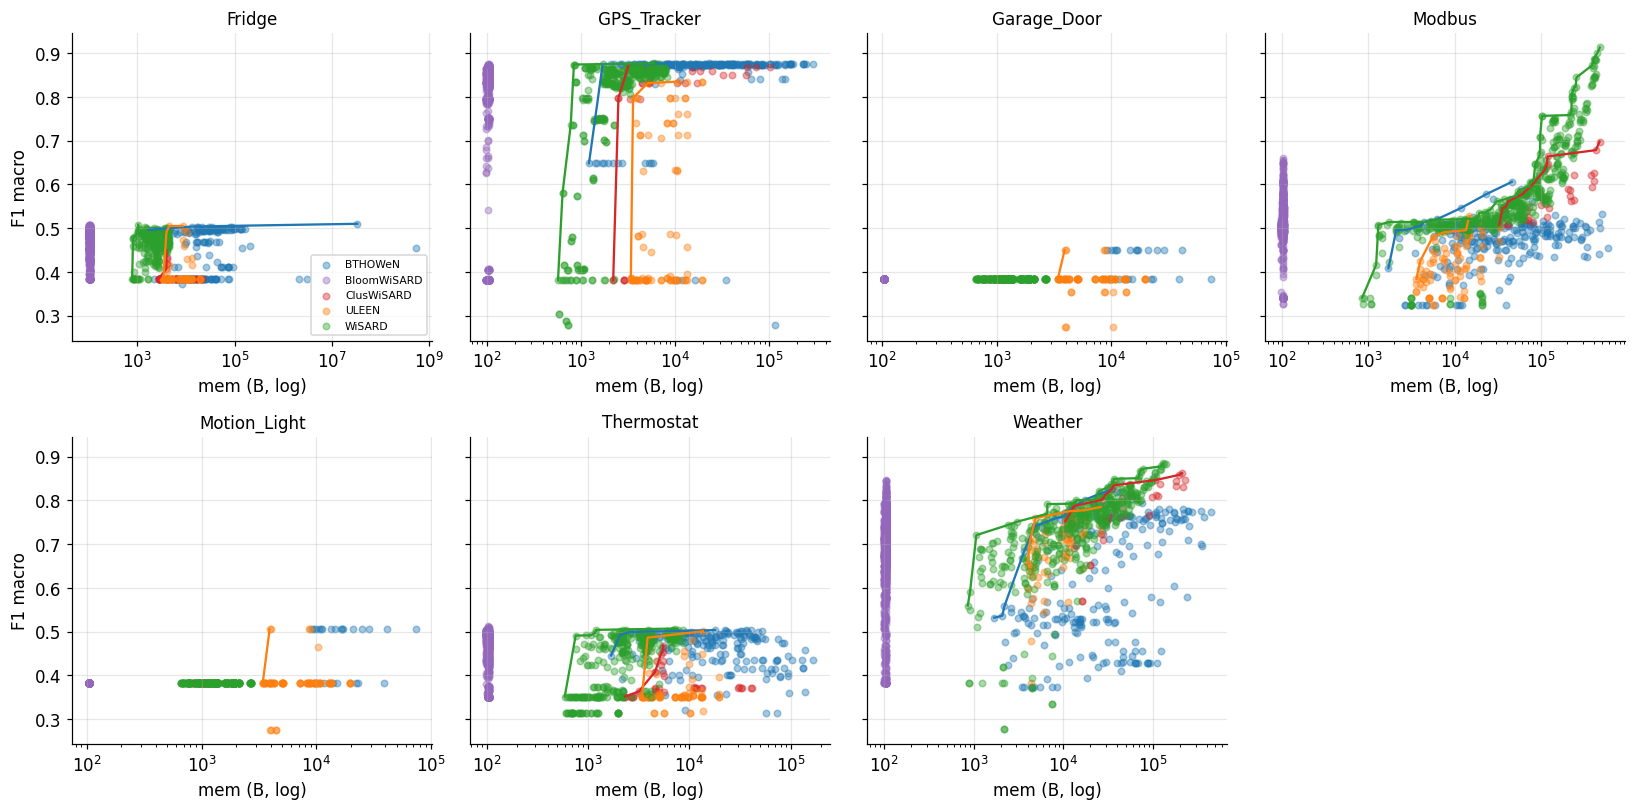

In [6]:
bases = sorted(df.base.dropna().unique())
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), sharey=True)
axes = axes.flatten()
for i, base in enumerate(bases):
    ax = axes[i]
    s = df[(df.base == base) & (df.task == "binary") & (~df.skipped)
           & df.memory_bytes_serialized.notna()
           & (df.memory_bytes_serialized > 0)
           & df.f1_macro.notna()
           & (df.submission != "bthowen_reference")]
    for model, g in s.groupby("model"):
        color = COLOR_BY_MODEL.get(model, "gray")
        ax.scatter(g.memory_bytes_serialized, g.f1_macro,
                   alpha=0.4, s=18, color=color, label=model)
        pts = list(zip(g.memory_bytes_serialized, g.f1_macro))
        mask = pareto_front(pts)
        front = g.iloc[mask].sort_values("memory_bytes_serialized")
        if mask.any():
            ax.plot(front.memory_bytes_serialized, front.f1_macro,
                    color=color, lw=1.5)
    ax.set_xscale("log")
    ax.set_title(base, fontsize=11)
    ax.grid(alpha=0.3)
    if i % 4 == 0:
        ax.set_ylabel("F1 macro")
    ax.set_xlabel("mem (B, log)")
    if i == 0:
        ax.legend(fontsize=7, loc="lower right")
for j in range(len(bases), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(FIGS / "v12_pareto_por_base.png")
plt.show()

## V13 — Best F1 modelo × base (bar grouped, novo)

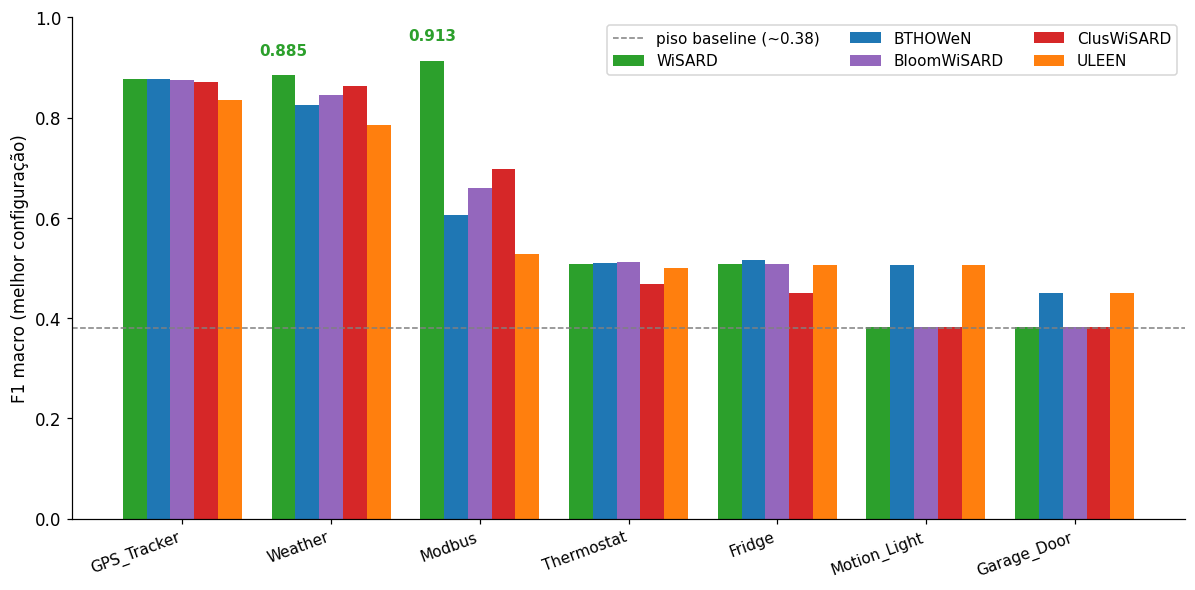

In [7]:
best = sw.best_per_base(df[df.task == "binary"], "f1_macro")
pivot = best.pivot(index="base", columns="model", values="f1_macro")
order = pivot.mean(axis=1).sort_values(ascending=False).index
pivot = pivot.loc[order]
models_in_order = ["WiSARD", "BTHOWeN", "BloomWiSARD", "ClusWiSARD", "ULEEN"]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(pivot.index))
w = 0.16
for i, m in enumerate(models_in_order):
    if m not in pivot.columns:
        continue
    bars = ax.bar(x + i * w, pivot[m], w, color=COLOR_BY_MODEL[m], label=m)
ax.axhline(0.38, color="gray", ls="--", lw=1, label="piso baseline (~0.38)")
ax.set_xticks(x + w * 2)
ax.set_xticklabels(pivot.index, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("F1 macro (melhor configuração)")
ax.set_ylim(0, 1)
ax.legend(ncol=3, fontsize=10, loc="upper right")
# Anotação destacando os vencedores WiSARD em Modbus e Weather
for base in ["Modbus", "Weather"]:
    if base in pivot.index and "WiSARD" in pivot.columns:
        bi = list(pivot.index).index(base)
        mi = models_in_order.index("WiSARD")
        v = pivot.loc[base, "WiSARD"]
        ax.annotate(f"{v:.3f}", xy=(bi + mi * w, v), xytext=(bi + mi * w, v + 0.04),
                    ha="center", fontsize=10, fontweight="bold",
                    color=COLOR_BY_MODEL["WiSARD"])
plt.tight_layout()
plt.savefig(FIGS / "v13_best_f1_modelo_base.png")
plt.show()

## V16 — Modbus: F1 vs addressSize por termômetro (novo)

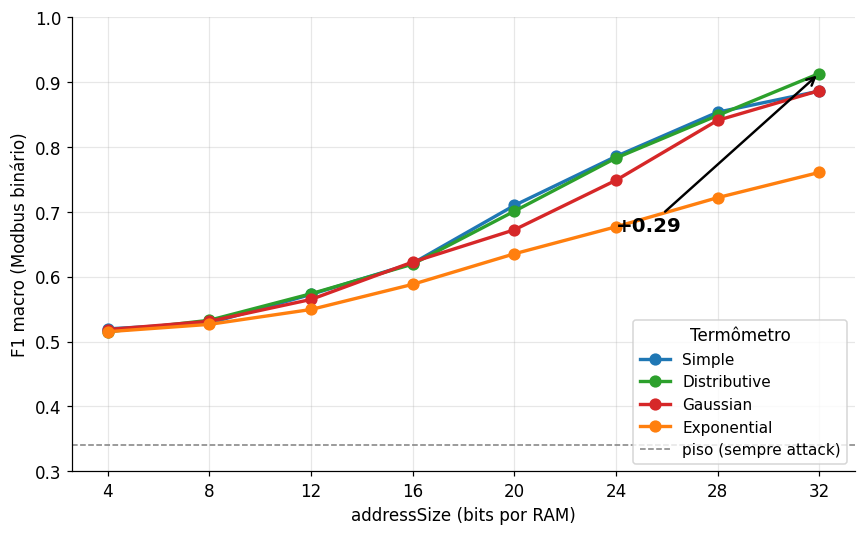

In [8]:
# WiSARD entrega + reference (junta as duas submissões pra ter o grid completo)
sub = df[(df.base == "Modbus") & (df.task == "binary")
         & (df.model == "WiSARD") & (~df.skipped) & df.f1_macro.notna()]
g = sub.groupby(["address_size", "encoder_type"])["f1_macro"].max().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for t in ["Simple", "Distributive", "Gaussian", "Exponential"]:
    gr = g[g.encoder_type == t].sort_values("address_size")
    if not len(gr):
        continue
    ax.plot(gr.address_size, gr.f1_macro, "-o",
            color=THERMO_COLORS[t], label=t, lw=2.2, ms=7)
ax.axhline(0.341, color="gray", ls="--", lw=1, label="piso (sempre attack)")
ax.set_xlabel("addressSize (bits por RAM)")
ax.set_ylabel("F1 macro (Modbus binário)")
ax.set_xticks([4, 8, 12, 16, 20, 24, 28, 32])
ax.set_ylim(0.30, 1.0)
ax.legend(loc="lower right", fontsize=10, title="Termômetro")
ax.grid(alpha=0.3)

# Anotação do salto
g_dist = g[g.encoder_type == "Distributive"].sort_values("address_size")
if len(g_dist):
    a, b = g_dist[g_dist.address_size == 16], g_dist[g_dist.address_size == 32]
    if len(a) and len(b):
        v16, v32 = float(a.f1_macro.iloc[0]), float(b.f1_macro.iloc[0])
        ax.annotate(f"+{v32 - v16:.2f}",
                    xy=(32, v32), xytext=(24, v16 + 0.05),
                    arrowprops=dict(arrowstyle="->", lw=1.6, color="black"),
                    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "v16_modbus_f1_vs_addrsize.png")
plt.show()

## V17 — Lift por base (piso → best, novo)

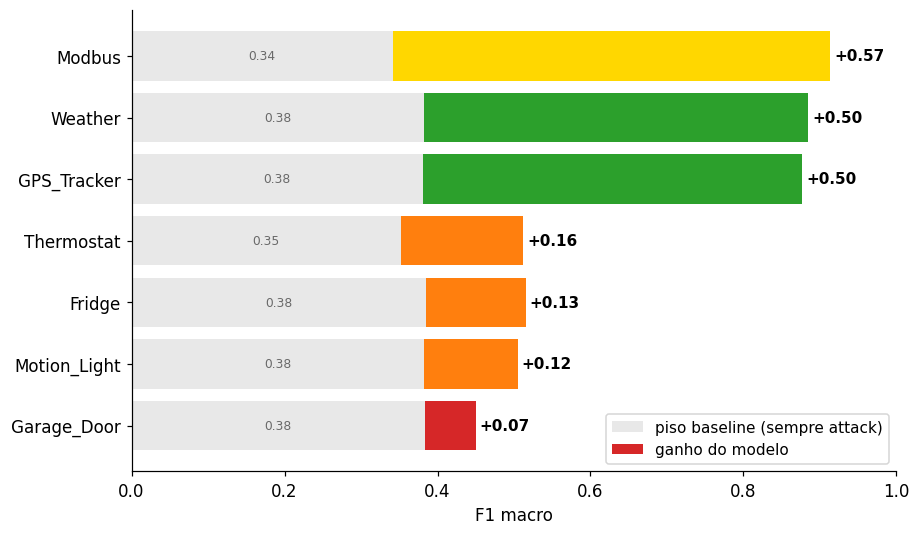

In [9]:
rows = []
for base in bases_order:
    d = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    _, te = sw.make_split(d, "label")
    piso = f1_score(te["label"], np.ones(len(te)), average="macro")
    best = df.query("base == @base and task == 'binary' and not skipped").f1_macro.max()
    rows.append({"base": base, "piso": piso, "best": best, "lift": best - piso})
lifts = pd.DataFrame(rows).sort_values("lift")

fig, ax = plt.subplots(figsize=(8.5, 5))
# Background bar (piso)
ax.barh(lifts.base, lifts.piso, color="lightgray", alpha=0.5,
        label="piso baseline (sempre attack)")
# Lift (colorido por tier)
colors = [TIER_COLORS[TIER_OF[b]] for b in lifts.base]
ax.barh(lifts.base, lifts.lift, left=lifts.piso, color=colors,
        label="ganho do modelo")
for i, (b, p, bst, lf) in enumerate(zip(lifts.base, lifts.piso, lifts.best, lifts.lift)):
    ax.text(bst + 0.005, i, f"+{lf:.2f}", va="center",
            fontsize=10, fontweight="bold")
    ax.text(p / 2, i, f"{p:.2f}", va="center", ha="center", fontsize=8, color="dimgray")
ax.set_xlim(0, 1)
ax.set_xlabel("F1 macro")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "v17_lift_por_base.png")
plt.show()

## V18 — BloomWiSARD vs WiSARD: F1 × memória (escala log)

Comparação direta com WiSARD pra dar noção de escala. BloomWiSARD comprime
tudo em ~100 B; WiSARD vai de ~600 B até ~500 KB. Diferença de 1-3 ordens
de magnitude visível em log scale.

BloomWiSARD memoria: 99-106 B
WiSARD      memoria: 574-473535 B


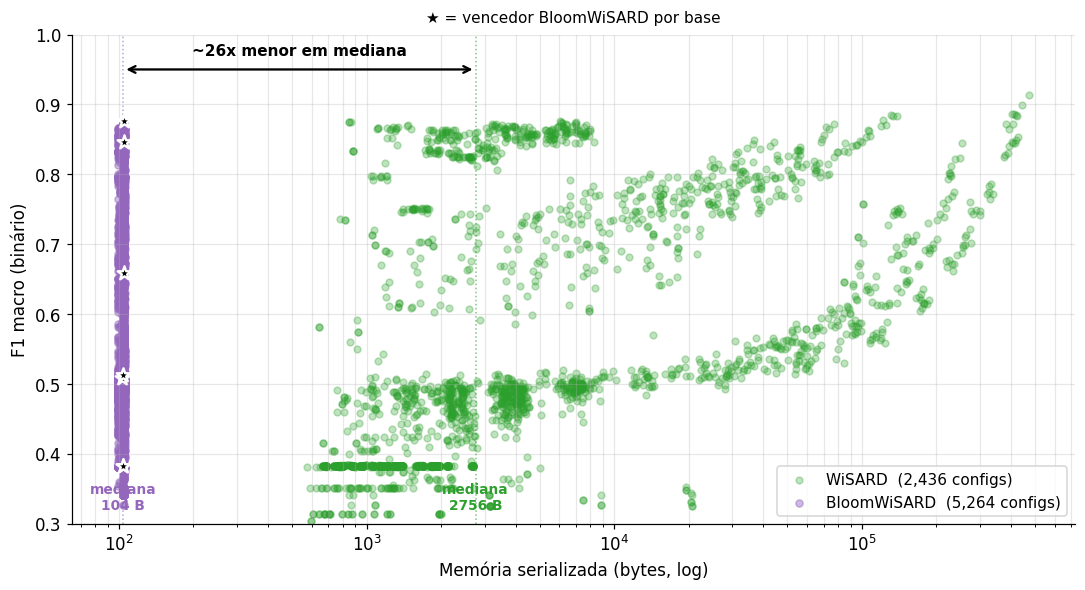

In [10]:
COMPARE_MODEL = "WiSARD"

bloom = df[(df.model == "BloomWiSARD") & (df.task == "binary")
           & (~df.skipped) & df.memory_bytes_serialized.notna()
           & (df.memory_bytes_serialized > 0) & df.f1_macro.notna()]
wis = df[(df.model == COMPARE_MODEL) & (df.task == "binary")
         & (~df.skipped) & df.memory_bytes_serialized.notna()
         & (df.memory_bytes_serialized > 0) & df.f1_macro.notna()]

print(f"BloomWiSARD memoria: {bloom.memory_bytes_serialized.min():.0f}"
      f"-{bloom.memory_bytes_serialized.max():.0f} B")
print(f"{COMPARE_MODEL}      memoria: {wis.memory_bytes_serialized.min():.0f}"
      f"-{wis.memory_bytes_serialized.max():.0f} B")

fig, ax = plt.subplots(figsize=(10, 5.5))
# Scatter dos dois modelos
ax.scatter(wis.memory_bytes_serialized, wis.f1_macro,
           color=COLOR_BY_MODEL[COMPARE_MODEL], alpha=0.30, s=20,
           label=f"{COMPARE_MODEL}  ({len(wis):,} configs)")
ax.scatter(bloom.memory_bytes_serialized, bloom.f1_macro,
           color=COLOR_BY_MODEL["BloomWiSARD"], alpha=0.45, s=22,
           label=f"BloomWiSARD  ({len(bloom):,} configs)")

# Marcar os bests do BloomWiSARD por base (estrelas)
for b in sorted(bloom.base.unique()):
    g = bloom[bloom.base == b]
    best = g.sort_values("f1_macro", ascending=False).iloc[0]
    ax.scatter(best.memory_bytes_serialized, best.f1_macro,
               color="black", s=90, marker="*", zorder=5,
               edgecolors="white", linewidths=1.5)

# Anotacoes destacando a escala
bloom_med = float(np.median(bloom.memory_bytes_serialized))
wis_med = float(np.median(wis.memory_bytes_serialized))
ax.axvline(bloom_med, color=COLOR_BY_MODEL["BloomWiSARD"], ls=":",
           lw=1, alpha=0.6)
ax.axvline(wis_med, color=COLOR_BY_MODEL[COMPARE_MODEL], ls=":",
           lw=1, alpha=0.6)
ax.text(bloom_med, 0.32, f"mediana\n{bloom_med:.0f} B",
        ha="center", fontsize=9,
        color=COLOR_BY_MODEL["BloomWiSARD"], fontweight="bold")
ax.text(wis_med, 0.32, f"mediana\n{wis_med:.0f} B",
        ha="center", fontsize=9,
        color=COLOR_BY_MODEL[COMPARE_MODEL], fontweight="bold")

# Anotar fator de compressao
ratio = wis_med / bloom_med
ax.annotate("", xy=(wis_med, 0.95), xytext=(bloom_med, 0.95),
            arrowprops=dict(arrowstyle="<->", lw=1.5, color="black"))
ax.text((bloom_med * wis_med) ** 0.5, 0.97,
        f"~{ratio:.0f}x menor em mediana",
        ha="center", fontsize=10, fontweight="bold")

ax.set_xscale("log")
ax.set_xlabel("Memória serializada (bytes, log)")
ax.set_ylabel("F1 macro (binário)")
ax.set_ylim(0.3, 1.0)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, which="both")
ax.set_title("★ = vencedor BloomWiSARD por base",
             fontsize=10, pad=8)
plt.tight_layout()
plt.savefig(FIGS / "v18_bloomwisard_f1_mem.png")
plt.show()


## V20 — Train time por submissão (boxplot, backup)

/var/folders/0d/r9sh3j7d0rdcmcq1w3l685600000gn/T/ipykernel_63891/2415328347.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True,


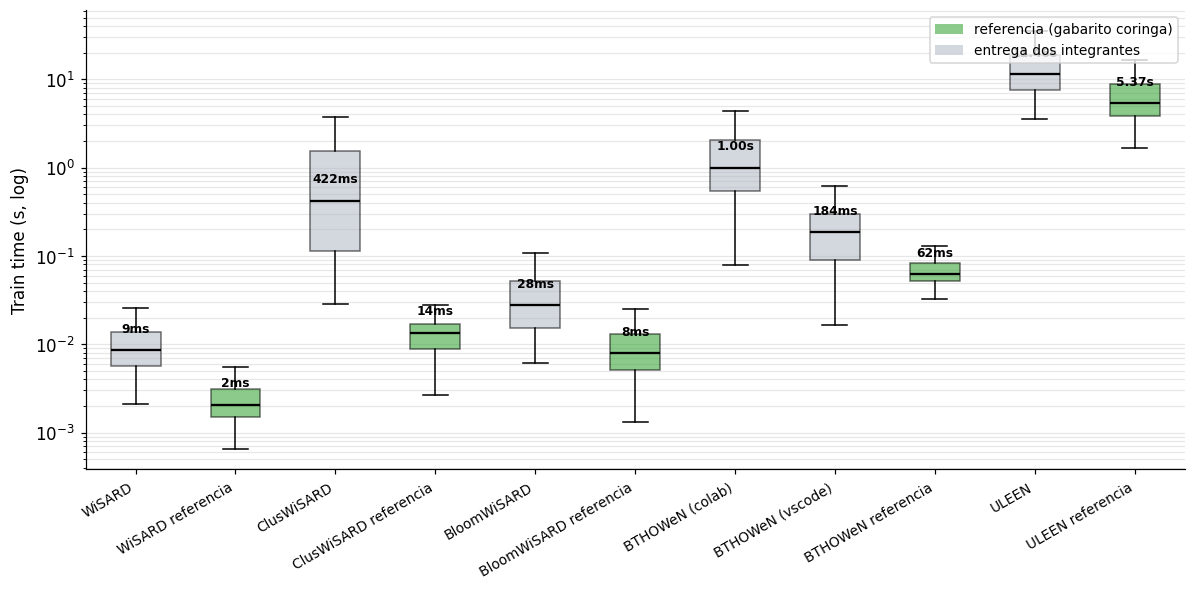

In [11]:
SUB_LABEL = {
    "wisard":                 "WiSARD",
    "wisard_reference":       "WiSARD referencia",
    "cluswisard_purepython":  "ClusWiSARD",
    "cluswisard_reference":   "ClusWiSARD referencia",
    "bloomwisard_purepython": "BloomWiSARD",
    "bloomwisard_reference":  "BloomWiSARD referencia",
    "bthowen_colab":          "BTHOWeN (colab)",
    "bthowen_vscode":         "BTHOWeN (vscode)",
    "bthowen_reference":      "BTHOWeN referencia",
    "uleen":                  "ULEEN",
    "uleen_reference":        "ULEEN referencia",
}
REF_COLOR = "#2ca02c"          # verde: tudo que e referencia
ENTREGA_COLOR = "#B0B7C3"      # cinza neutro: entregas dos integrantes

sub = df[(~df.skipped) & df.train_time_s.notna() & (df.train_time_s > 0)]
order = [s for s in [
    "wisard", "wisard_reference",
    "cluswisard_purepython", "cluswisard_reference",
    "bloomwisard_purepython", "bloomwisard_reference",
    "bthowen_colab", "bthowen_vscode", "bthowen_reference",
    "uleen", "uleen_reference",
] if s in sub.submission.unique()]
labels = [SUB_LABEL[s] for s in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
data = [sub[sub.submission == s].train_time_s.values for s in order]
bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True,
                medianprops=dict(color="black", lw=1.5))
for patch, s in zip(bp["boxes"], order):
    is_ref = s.endswith("_reference")
    patch.set_facecolor(REF_COLOR if is_ref else ENTREGA_COLOR)
    patch.set_alpha(0.55)
for i, s in enumerate(order, start=1):
    med = np.median(sub[sub.submission == s].train_time_s.values)
    ax.text(i, med * 1.6, f"{med:.2f}s" if med >= 1 else f"{med*1000:.0f}ms",
            ha="center", fontsize=8, fontweight="bold")
ax.set_yscale("log")
ax.set_ylabel("Train time (s, log)")
plt.xticks(rotation=30, ha="right", fontsize=9)
ax.grid(alpha=0.3, axis="y", which="both")
# Legenda simples
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=REF_COLOR, alpha=0.55, label="referencia (gabarito coringa)"),
                   Patch(facecolor=ENTREGA_COLOR, alpha=0.55, label="entrega dos integrantes")],
          loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "v20_train_time_boxplot.png")
plt.show()


## V21 — Inference latency por submissão (boxplot, backup)

/var/folders/0d/r9sh3j7d0rdcmcq1w3l685600000gn/T/ipykernel_63891/1638524622.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True,


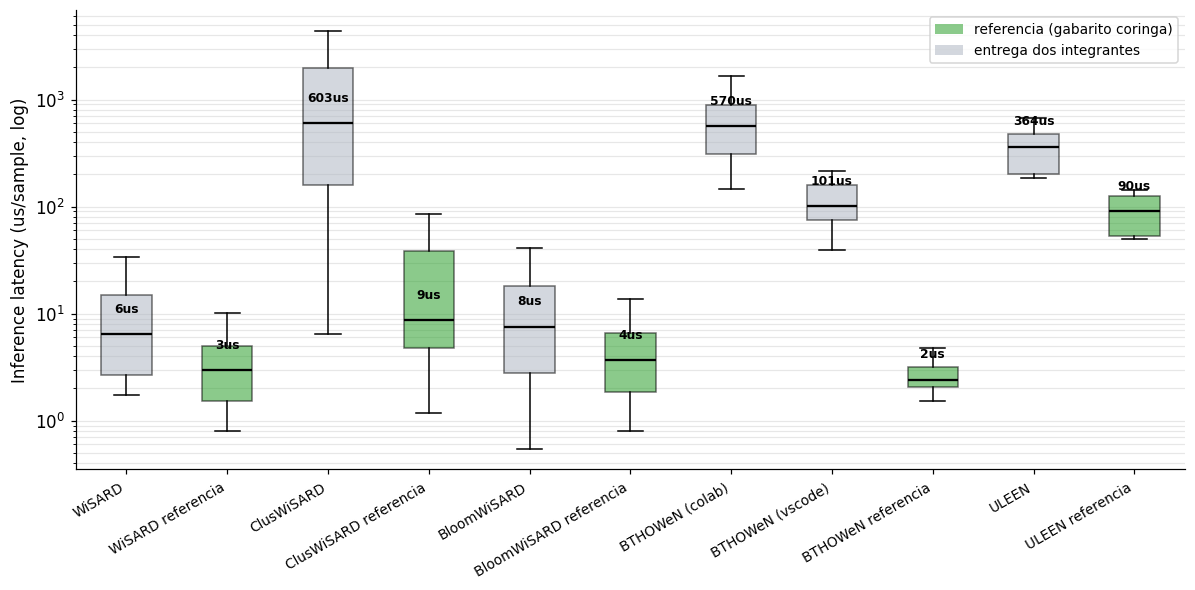

In [12]:
SUB_LABEL = {
    "wisard":                 "WiSARD",
    "wisard_reference":       "WiSARD referencia",
    "cluswisard_purepython":  "ClusWiSARD",
    "cluswisard_reference":   "ClusWiSARD referencia",
    "bloomwisard_purepython": "BloomWiSARD",
    "bloomwisard_reference":  "BloomWiSARD referencia",
    "bthowen_colab":          "BTHOWeN (colab)",
    "bthowen_vscode":         "BTHOWeN (vscode)",
    "bthowen_reference":      "BTHOWeN referencia",
    "uleen":                  "ULEEN",
    "uleen_reference":        "ULEEN referencia",
}
REF_COLOR = "#2ca02c"          # verde: tudo que e referencia
ENTREGA_COLOR = "#B0B7C3"      # cinza neutro: entregas dos integrantes

sub = df[(~df.skipped) & df.inference_latency_us.notna() & (df.inference_latency_us > 0)]
order = [s for s in [
    "wisard", "wisard_reference",
    "cluswisard_purepython", "cluswisard_reference",
    "bloomwisard_purepython", "bloomwisard_reference",
    "bthowen_colab", "bthowen_vscode", "bthowen_reference",
    "uleen", "uleen_reference",
] if s in sub.submission.unique()]
labels = [SUB_LABEL[s] for s in order]

fig, ax = plt.subplots(figsize=(11, 5.5))
data = [sub[sub.submission == s].inference_latency_us.values for s in order]
bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True,
                medianprops=dict(color="black", lw=1.5))
for patch, s in zip(bp["boxes"], order):
    is_ref = s.endswith("_reference")
    patch.set_facecolor(REF_COLOR if is_ref else ENTREGA_COLOR)
    patch.set_alpha(0.55)
for i, s in enumerate(order, start=1):
    med = np.median(sub[sub.submission == s].inference_latency_us.values)
    label = f"{med:.0f}us" if med < 1000 else f"{med/1000:.1f}ms"
    ax.text(i, med * 1.6, label, ha="center", fontsize=8, fontweight="bold")
ax.set_yscale("log")
ax.set_ylabel("Inference latency (us/sample, log)")
plt.xticks(rotation=30, ha="right", fontsize=9)
ax.grid(alpha=0.3, axis="y", which="both")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=REF_COLOR, alpha=0.55, label="referencia (gabarito coringa)"),
                   Patch(facecolor=ENTREGA_COLOR, alpha=0.55, label="entrega dos integrantes")],
          loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "v21_inference_latency_boxplot.png")
plt.show()


## V14 — Matrizes de confusão dos vencedores (binário)

Re-renderiza usando a função `plot_confusion` com orientação consistente
(positivo = ataque = índice 1) e anotações TN/FP/FN/TP nos cantos.

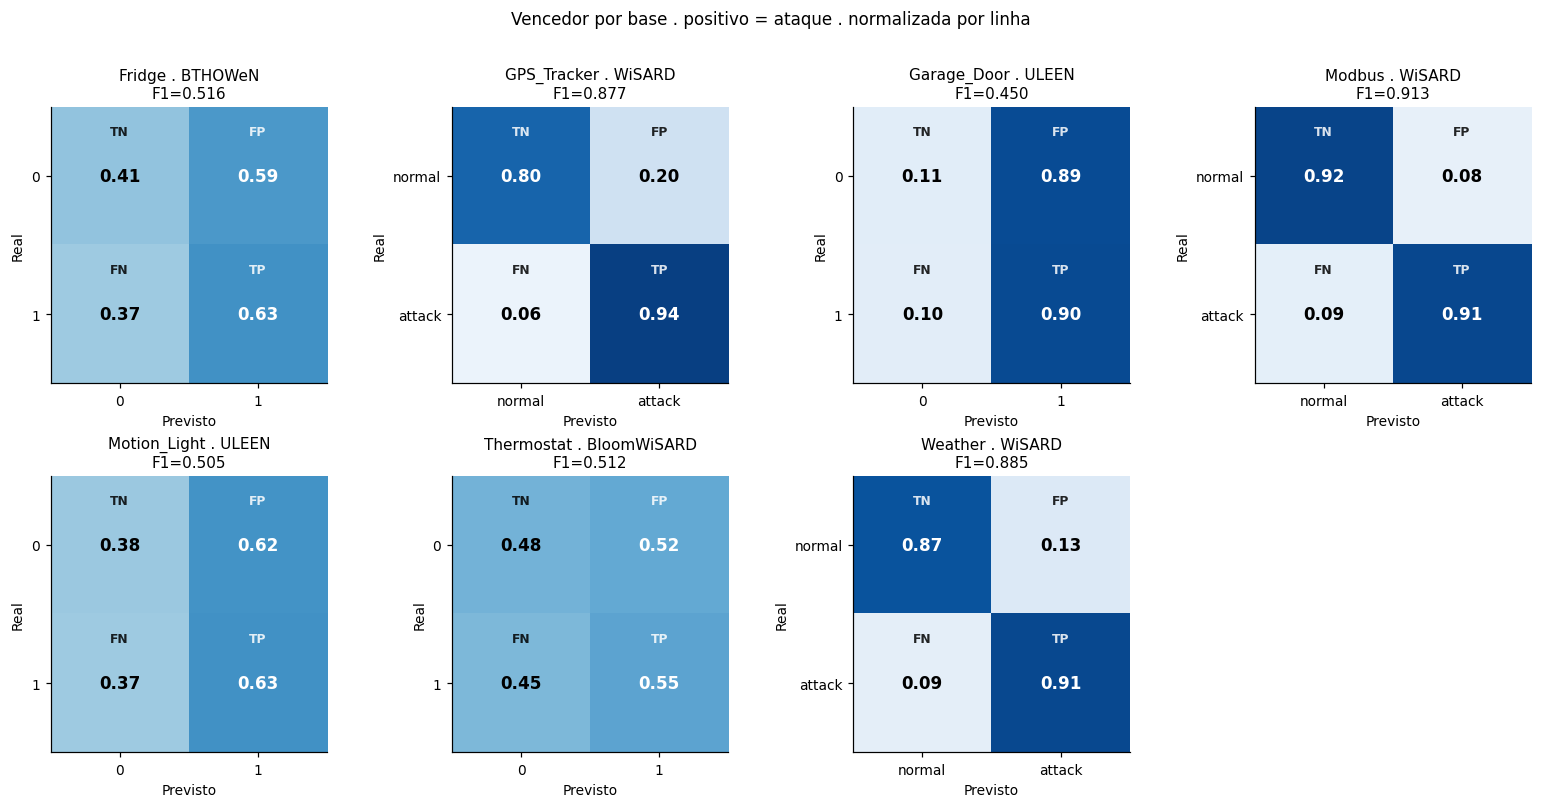

In [13]:
def _orient_binary(cm, labels):
    if cm.shape != (2, 2) or not labels or len(labels) != 2:
        return cm, labels
    POS = {"1", "attack", "anomaly", "positive"}
    lo = [str(x).strip().lower() for x in labels]
    if lo[0] in POS and lo[1] not in POS:
        cm = cm[[1, 0]][:, [1, 0]]
        labels = [labels[1], labels[0]]
    return cm, labels

def plot_cm(ax, cm, labels, title):
    cm = np.array(cm, dtype=float)
    if cm.size == 0:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax.set_title(title, fontsize=10); ax.axis("off"); return
    cm, labels = _orient_binary(cm, list(labels))
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for (i, j), v in np.ndenumerate(norm):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.5 else "black",
                fontsize=11, fontweight="bold")
    if cm.shape == (2, 2):
        quad = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}
        for (i, j), tag in quad.items():
            ax.text(j, i - 0.32, tag, ha="center", va="center",
                    color="white" if norm[i, j] > 0.5 else "black",
                    fontsize=8, fontweight="bold", alpha=0.85)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Previsto", fontsize=9)
    ax.set_ylabel("Real", fontsize=9)
    ax.set_title(title, fontsize=10)

# Vencedores cross-model por base, com OVERRIDE pra GPS_Tracker:
# BTHOWeN colab (0.876877) e WiSARD entrega (0.876853) empatam nas
# 4as casas — forcamos WiSARD pra manter coerencia narrativa.
best_bin = sw.best_per_base(df[df.task == "binary"], "f1_macro")
winners = (best_bin.sort_values("f1_macro", ascending=False)
                   .drop_duplicates(subset=["base"], keep="first"))
# Override GPS_Tracker -> melhor cfg WiSARD
gps_wisard = (df[(df.base == "GPS_Tracker") & (df.task == "binary")
                 & (df.model == "WiSARD") & (~df.skipped)
                 & df.f1_macro.notna()]
              .sort_values("f1_macro", ascending=False).head(1))
winners = winners[winners.base != "GPS_Tracker"]
winners = pd.concat([winners, gps_wisard], ignore_index=True)
winners = winners.sort_values("base").reset_index(drop=True)

n, ncol = len(winners), 4
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.6 * nrow))
axes = axes.flatten() if n > 1 else [axes]
for i, (_, row) in enumerate(winners.iterrows()):
    title = f"{row['base']} . {row['model']}\nF1={row['f1_macro']:.3f}"
    plot_cm(axes[i], row.confusion_matrix, row.labels or [], title)
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.suptitle("Vencedor por base . positivo = ataque . normalizada por linha",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "v14_cms_binarios.png")
plt.show()


## V15 — Matrizes de confusão multi-classe (sobreviventes)

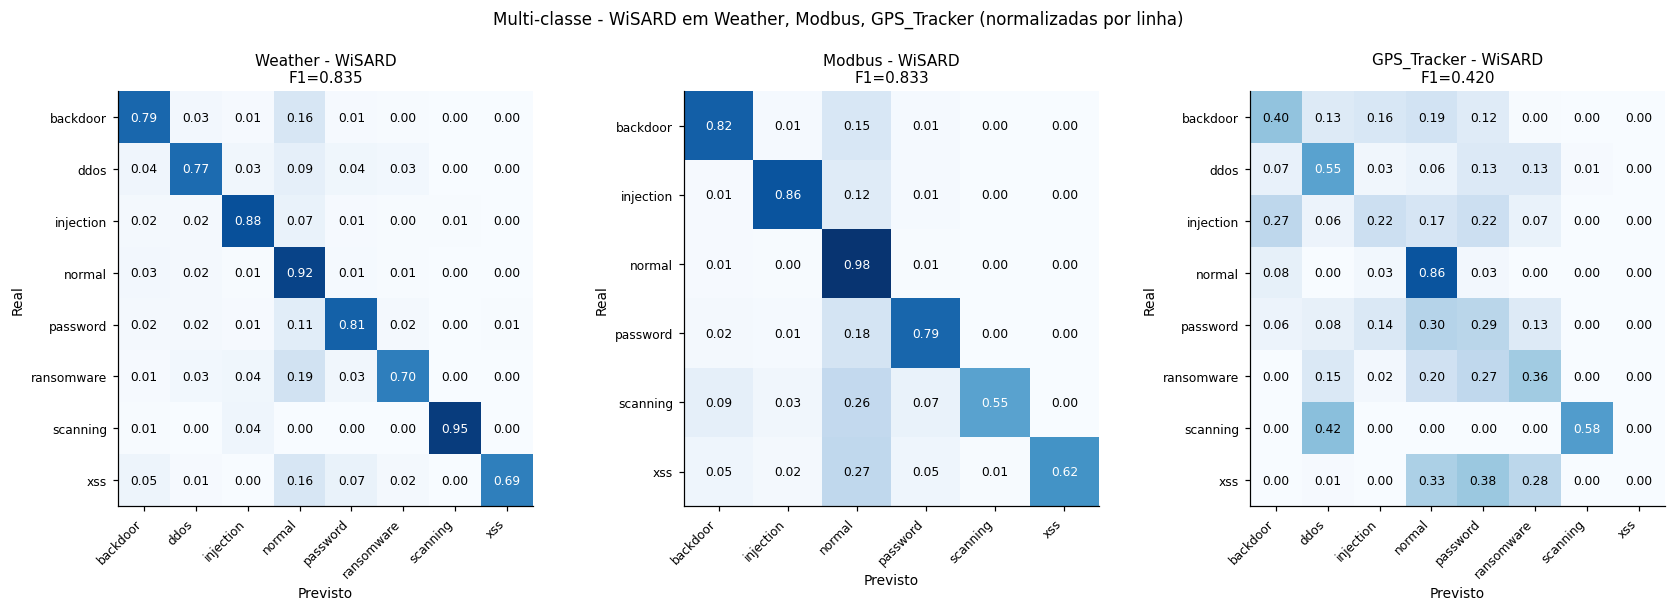

In [14]:
# Forcar WiSARD nos 3 sobreviventes (GPS_Tracker tava empatado com
# BloomWiSARD nas ultimas casas decimais — 0.420 vs 0.428 — e fica mais
# coerente narrativamente mostrar WiSARD em todos).
SURVIVORS = ["Weather", "Modbus", "GPS_Tracker"]
mc = df[(df.task == "multiclass") & (df.model == "WiSARD")
        & (~df.skipped) & df.f1_macro.notna()
        & df.base.isin(SURVIVORS)]
# Melhor cfg WiSARD por base
survivors = (mc.sort_values("f1_macro", ascending=False)
               .drop_duplicates(subset=["base"], keep="first")
               .set_index("base").loc[SURVIVORS].reset_index())

n, ncol = len(survivors), 3
fig, axes = plt.subplots(1, ncol, figsize=(5.2 * ncol, 5.2))
axes = axes if hasattr(axes, "__len__") else [axes]
for i, (_, row) in enumerate(survivors.iterrows()):
    cm = np.array(row.confusion_matrix, dtype=float)
    if cm.size == 0:
        axes[i].axis("off"); continue
    labels = row.labels or []
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    axes[i].imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for (a, b), v in np.ndenumerate(norm):
        axes[i].text(b, a, f"{v:.2f}", ha="center", va="center",
                     color="white" if v > 0.5 else "black", fontsize=8)
    axes[i].set_xticks(range(len(labels)))
    axes[i].set_yticks(range(len(labels)))
    axes[i].set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    axes[i].set_yticklabels(labels, fontsize=8)
    axes[i].set_xlabel("Previsto", fontsize=9)
    axes[i].set_ylabel("Real", fontsize=9)
    axes[i].set_title(f"{row.base} - WiSARD\nF1={row.f1_macro:.3f}",
                      fontsize=10)
plt.suptitle("Multi-classe - WiSARD em Weather, Modbus, GPS_Tracker "
             "(normalizadas por linha)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "v15_cms_multiclass.png")
plt.show()


## VC — Matrizes de associação feature × feature × label (Cramér's V por base)

Pedido extra: pra entender a relação entre as features de cada base.

- Numéricas contínuas são discretizadas em 10 quantis antes do qui-quadrado.
- Métrica: Cramér's V — 0 = independência, 1 = associação perfeita.
- A última coluna/linha é o **label**, então dá pra ver de relance
  qual feature isoladamente prevê melhor a anomalia.

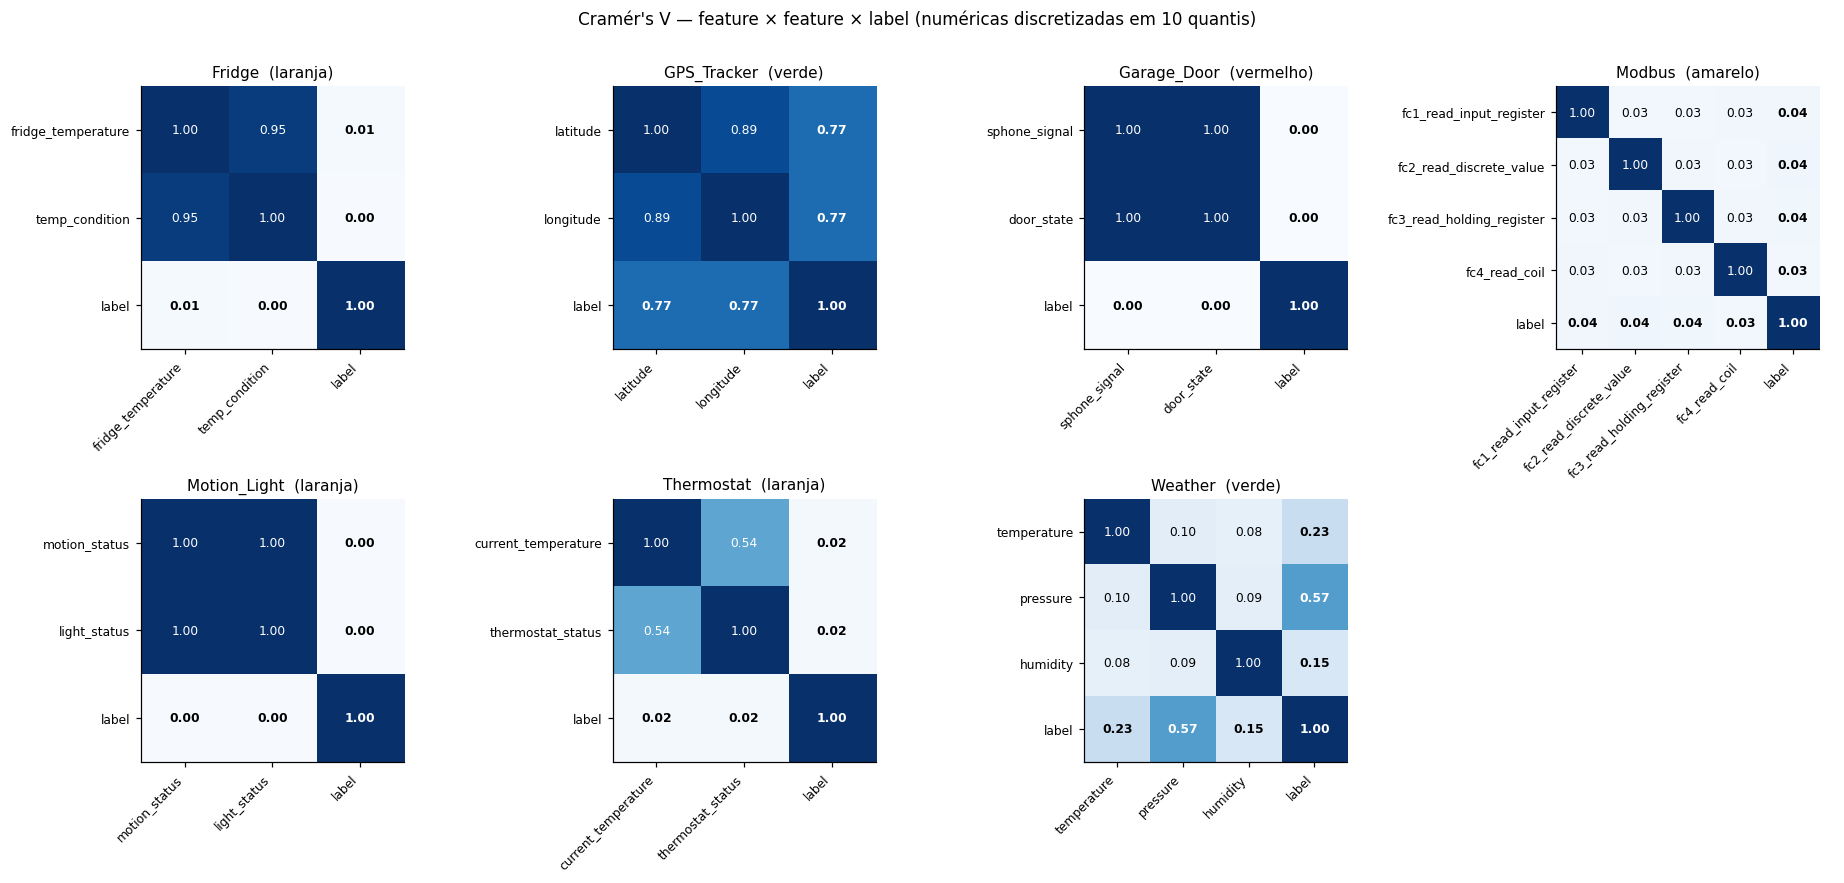

In [15]:
def assoc_matrix(base):
    d = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    num, cat = sw.FEATURE_COLS[base]
    cols = num + cat + ["label"]
    n = len(cols)
    M = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            v = cramers_v(discretize(d[cols[i]]), discretize(d[cols[j]]))
            M[i, j] = M[j, i] = v
    return cols, M

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.flatten()
for ax, base in zip(axes, bases_order):
    cols, M = assoc_matrix(base)
    im = ax.imshow(M, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(cols, fontsize=8)
    for (i, j), v in np.ndenumerate(M):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.5 else "black", fontsize=8,
                fontweight="bold" if (cols[i] == "label" or cols[j] == "label") else "normal")
    ax.set_title(f"{base}  ({TIER_OF[base]})", fontsize=10)
# Hide unused
for j in range(len(bases_order), len(axes)):
    axes[j].axis("off")
plt.suptitle("Cramér's V — feature × feature × label (numéricas discretizadas em 10 quantis)",
             y=1.0, fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "vC_associacao_features.png")
plt.show()

## Sumário — checklist

In [16]:
for p in sorted(FIGS.glob("*.png")):
    print(f"  {p.name}  ({p.stat().st_size // 1024} KB)")

  v02_attack_pct.png  (43 KB)
  v03_heatmap_base_attack.png  (79 KB)
  v06_cramers_v_por_base.png  (36 KB)
  v11_pareto_cross_model.png  (284 KB)
  v12_pareto_por_base.png  (353 KB)
  v13_best_f1_modelo_base.png  (62 KB)
  v14_cms_binarios.png  (111 KB)
  v15_cms_multiclass.png  (168 KB)
  v16_modbus_f1_vs_addrsize.png  (84 KB)
  v17_lift_por_base.png  (43 KB)
  v18_bloomwisard_f1_mem.png  (234 KB)
  v20_train_time_boxplot.png  (88 KB)
  v21_inference_latency_boxplot.png  (90 KB)
  vC_associacao_features.png  (205 KB)
